# Understanding Straight vs Curved Fits and Polynomial Regression

* Curve ≠ non-linear model
* Polynomial Regression = Linear Regression + feature expansion
* Curves mean changing slope
* PolynomialFeatures only creates columns
* Overfitting is the real danger, not non-linearity

---

## 1️ What Does a Straight Line vs Curved Line Actually Tell You?

### When You See a **Straight Line Fit**

**Interpretation:**
- The model assumes a **constant rate of change**
- If `x` increases by 1, `y` always changes by the same amount

**Example:**
salary = 20,000 + 3,000 × experience


This means:
- Each additional year of experience adds the **same salary increment**
- The relationship is simple and predictable

 This works **only if reality behaves linearly**

---

### When You See a **Curved Fit**

**Interpretation:**
- The effect of `x` on `y` depends on the value of `x`
- The rate of change is **not constant**

**Examples:**
- Learning speed vs time
- Price vs demand
- Accuracy vs training size

 This is where **polynomial terms help**

---

## 2️ Why Do We Use Polynomial Regression?

### Problem with Plain Linear Regression

Linear regression assumes:
Δy / Δx = constant


But many real-world relationships look like:
- Slow → fast → saturation
- Fast growth → plateau
- Diminishing returns

A straight line **cannot bend** to match these patterns.

---

### What Polynomial Regression Actually Does

Polynomial regression:
-  Does **not** change the model
-  Changes the **features** you give to the model

From:
x


To:


x, x², x³


This allows the model to:
- Increase slope
- Decrease slope
- Turn direction

---

###  Key Intuition (Very Important)

> **Polynomial terms allow the slope itself to change**

That’s it.  
That’s the entire reason polynomial regression exists.

---

## 3️ Straight vs Curved: What Conclusion Should YOU Make?

### Case A: Straight Line Fits Well

**Interpretation:**
- Relationship is approximately linear
- Simpler model is better
- Low variance and high interpretability

 Use:
- Linear Regression
- Ridge Regression
- Lasso Regression

---

### Case B: Straight Line Underfits, Curve Fits Better

**Interpretation:**
- Relationship is non-linear in input
- Linear assumption is too restrictive

 Use:
- Polynomial Regression **with regularization**

---

### Case C: Highly Wiggly Curve

**Interpretation:**
- Model is memorizing noise
- High variance

 Overfitting  
➡ Reduce polynomial degree or add regularization

---

## 4️ Is There a Direct Library for Polynomial Regression?

 There is **no standalone `PolynomialRegression` model**

**Why?**  
Because:
> Polynomial Regression is still **Linear Regression**

---

### sklearn’s Approach (Explicit and Clean)

```python
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

```

They separate concerns:
- Feature engineering → PolynomialFeatures

- Model → LinearRegression



How Implementation ACTUALLY Works (Step-by-Step)
* Step 1: Original Data
    - X = [x]

* Step 2: Expand Features
    - poly = PolynomialFeatures(degree=2, include_bias=True)
    - X_poly = poly.fit_transform(X)

* Now:
    - X_poly = [1, x, x²]



* Step 3: Apply Linear Regression
    - model = LinearRegression()
    - model.fit(X_poly, y)


* The learned model is:
    - y = w₀ + w₁x + w₂x²

✔ No new algorithm
✔ No new optimizer
✔ Same OLS / Gradient Descent

---

### 6 Why sklearn Does It This Way (Important Design Reason)

>This design allows easy combinations:

* Polynomial + Ridge
* Polynomial + Lasso
* Polynomial + ElasticNet

```python
Example Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

Pipeline([
    ("poly", PolynomialFeatures(degree=3)),
    ("model", Ridge(alpha=1.0))
])
```

This is industry-grade ML design.
---

### 7️ When Should YOU Use Polynomial Regression?

**Use It When:**

- Linear model underfits
- Data is low-dimensional 
- You want interpretability
- You understand bias–variance tradeoff

**Avoid It When:**

- Data is high-dimensional
- Large polynomial degree is required
- Data is very noisy

### 8️ One Mental Picture 

* Linear Regression: ---> “y changes at a constant speed”

* Polynomial Regression: ---->“the speed of change itself can change”

That’s the entire story.

In [3]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# Simple non-linear data
np.random.seed(42)
X = np.linspace(-3, 3, 50).reshape(-1, 1)
y = 1 + 2*X + 0.5*(X**2) + np.random.randn(50, 1)


In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline


In [6]:
model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=True)),
    ("linear", LinearRegression())
])


In [7]:
model.fit(X, y)


,steps,"[('poly', ...), ('linear', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [8]:
y_pred_sklearn = model.predict(X)


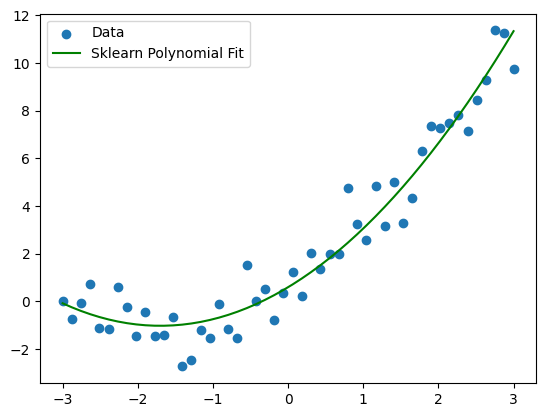

In [9]:
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred_sklearn, color="green", label="Sklearn Polynomial Fit")
plt.legend()
plt.show()


In [12]:
from sklearn.linear_model import Ridge

model = Pipeline([
    ("poly", PolynomialFeatures(degree=5)),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(X, y)
y_pred = model.predict(X)


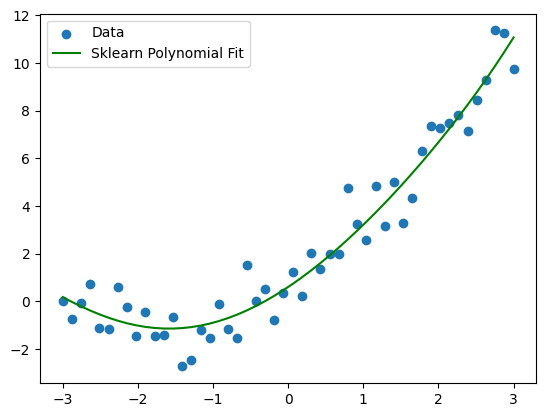

In [11]:
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, color="green", label="Sklearn Polynomial Fit")
plt.legend()
plt.show()

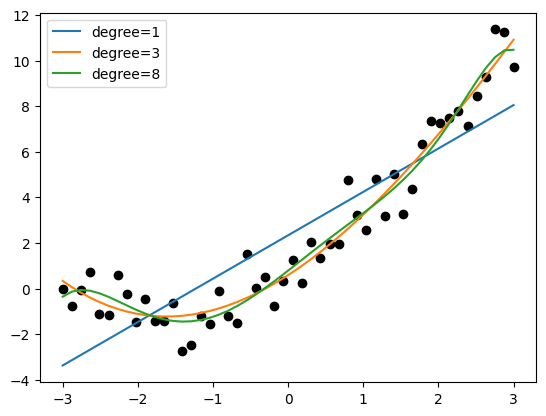

In [13]:
for d in [1, 3, 8]:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("linear", LinearRegression())
    ])
    model.fit(X, y)
    plt.plot(X, model.predict(X), label=f"degree={d}")

plt.scatter(X, y, color="black")
plt.legend()
plt.show()


---


# When to Use Polynomial Regression — and When NOT To

Polynomial Regression is one of the most misunderstood tools in Machine Learning.
This document exists to **build correct judgment**, not just technical knowledge.

---

## 1️ What Polynomial Regression Actually Is

Polynomial Regression is:

> **Linear Regression applied on polynomially expanded features**

It does **NOT** change the learning algorithm.  
It changes the **representation of input data**.

Example:
x → [1, x, x², x³]

The model remains:
y = w₀ + w₁x + w₂x² + w₃x³

✔ Linear in parameters  
✔ Solved using OLS / Gradient Descent

---

## 2️ Why Polynomial Regression Exists

Plain Linear Regression assumes:
Δy / Δx = constant



But many real-world relationships show:
- Changing rate of growth
- Saturation effects
- Diminishing returns

Polynomial features allow:
- The slope to increase
- The slope to decrease
- The slope to change direction

> **Polynomial Regression allows the slope itself to change**

That is its only purpose.

---

## 3️ When You SHOULD Use Polynomial Regression

###  Use Polynomial Regression When:

#### 1. You Have Few Features
- Typically **1–5 input features**
- Feature explosion is manageable

---

#### 2. Linear Model Underfits
- Straight line clearly misses the pattern
- Training and test error both high

---

#### 3. You Want Interpretability
- Coefficients still have meaning
- Easier to explain than trees or neural networks

---

#### 4. You Control Model Capacity
- Low polynomial degree (≤ 2 or 3)
- Regularization is applied (Ridge / Lasso)

---

#### 5. You Are Learning Core ML Concepts
Polynomial regression is excellent for understanding:
- Bias–variance tradeoff
- Overfitting
- Feature engineering
- Model capacity

---

## 4️ When You Should NOT Use Polynomial Regression

###  Avoid Polynomial Regression When:

---

#### 1. You Have Many Features
PolynomialFeatures scales **combinatorially**.

Example:
- 100 features + degree 3 → **176,851 features**

This causes:
- Memory explosion
- Slow training
- Numerical instability

---

#### 2. Data Is High-Dimensional and Sparse
- Polynomial expansion makes data even sparser
- Generalization collapses

---

#### 3. You Need High Degree to Fit Data
- Large degree = high variance
- Model starts memorizing noise

This is a red flag:
> *Wrong model choice, not lack of complexity*

---

#### 4. Data Is Very Noisy
- Polynomial terms amplify noise
- Overfitting becomes severe

---

#### 5. You Have Large-Scale or Production Data
- Poor scalability
- Hard to maintain
- Fragile to distribution shifts

---

## 5️ Why Regularization Is NOT Enough

Regularization helps control **overfitting**, but it does **not** fix:

- Feature explosion
- Memory usage
- Computational cost

> Regularization controls **weights**, not **feature count**

---

## 6️ Safer Variants (If You Must Use It)

### ✔ Use Interaction-Only Features
```python
PolynomialFeatures(degree=2, interaction_only=True)

```
---

- Avoids powers like x², x³

- Keeps only meaningful feature interactions 

- Slower feature growth

- ✔ Always Combine With Regularization
    - PolynomialFeatures + Ridge / Lasso


- Never use high-degree polynomial regression without it.
---

### 7️ Better Alternatives in Practice

|Situation	|Better Choice|
|---------|-----------|
|Many features	|Tree-based models|
|Complex interactions	|Random Forest / Gradient Boosting|
|Smooth non-linearity	|Kernel methods|
|Large datasets	|Neural Networks|

Polynomial regression is not the final answer — it is a stepping stone.

---

In [14]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np


In [15]:
def count_features(n_features, degree):
    X_dummy = np.zeros((1, n_features))
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly.fit_transform(X_dummy)
    return X_poly.shape[1]


In [16]:
for n in [2, 5, 10, 50, 100]:
    for d in [2, 3]:
        print(f"n_features={n}, degree={d} → total_features={count_features(n, d)}")
    print("-" * 50)


n_features=2, degree=2 → total_features=6
n_features=2, degree=3 → total_features=10
--------------------------------------------------
n_features=5, degree=2 → total_features=21
n_features=5, degree=3 → total_features=56
--------------------------------------------------
n_features=10, degree=2 → total_features=66
n_features=10, degree=3 → total_features=286
--------------------------------------------------
n_features=50, degree=2 → total_features=1326
n_features=50, degree=3 → total_features=23426
--------------------------------------------------
n_features=100, degree=2 → total_features=5151
n_features=100, degree=3 → total_features=176851
--------------------------------------------------


In [17]:
n_samples = 10_000
n_features = 50
degree = 3

X = np.random.randn(n_samples, n_features)
poly = PolynomialFeatures(degree=degree)

X_poly = poly.fit_transform(X)

In [18]:
print("Original X shape:", X.shape)
print("Polynomial X shape:", X_poly.shape)
print("Memory used (MB):", X_poly.nbytes / 1e6)

Original X shape: (10000, 50)
Polynomial X shape: (10000, 23426)
Memory used (MB): 1874.08


Almost 2 GB RAM for ONE transformation.

In [19]:
from sklearn.linear_model import LinearRegression
import time

model = LinearRegression()

start = time.time()
model.fit(X_poly, np.random.randn(n_samples))
end = time.time()

print("Training time (seconds):", end - start)


Training time (seconds): 309.3449351787567


Notice CPU spike and Computation time